In [132]:
import os
import sys
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from glob import glob
from matplotlib import rcParams

#%matplotlib inline

# plot style
rcParams['mathtext.fontset'] = 'stix'
rcParams['font.family'] = 'STIXGeneral'
rcParams['figure.figsize'] = [16, 6]
rcParams['font.size'] = 22
rcParams['axes.labelsize'] = 20
rcParams['axes.titlesize'] = 20
rcParams['legend.fontsize'] = 16
rcParams['xtick.labelsize'] = 12
rcParams['ytick.labelsize'] = 16

from mpl_toolkits.mplot3d import Axes3D  

# to prevent ROOT errors
root_path = "/scratch/elena/root-6.26.04-install"
os.environ["ROOTSYS"] = root_path
os.environ["PYTHONPATH"] = f"{root_path}/lib:{os.environ.get('PYTHONPATH', '')}"
os.environ["LD_LIBRARY_PATH"] = f"{root_path}/lib:{os.environ.get('LD_LIBRARY_PATH', '')}"
sys.path.append(f"{root_path}/lib")

#set variables so functions_bonsai can locate required files
os.environ["WCSIM_BUILD_DIR"] = "/scratch/elena/wcsim-install"
os.environ["BONSAIDIR"] = "/scratch/elena/bonsai"


sys.path.append("/scratch/elena/9Li/scripts")
import functions_bonsai
import functions_multilateration

# -------------------------------
# load processed data (PKL)
# -------------------------------

processed_folder = "/scratch/elena/9Li/results/run1848/processed"
processed_files = sorted(glob(f"{processed_folder}/*.pkl"))

match = re.search(r'run(\d+)', processed_folder)
if match:
    run_number = match.group(1) 
    print(f"Run number: {run_number}")
else:
    run_number = "Not found!"


print(f"Found {len(processed_files)} processed files.")

if len(processed_files) > 0:
    geo_data = functions_bonsai.get_geo_mapping()
    lookup = functions_bonsai.build_lookup_table(geo_data)


    dfs = [pd.read_pickle(f) for f in processed_files]
    df_all = pd.concat(dfs, ignore_index=True)

    print(f"Total clusters loaded: {len(df_all)}")

    # chi2/ndof
    if 'chi2_ndof' in df_all.columns:
        valid_fits = df_all[df_all['fit_success'] == True]
        print(f"Fit success: {len(valid_fits)}")

Run number: 1848
Found 48 processed files.
Total clusters loaded: 661773
Fit success: 651850


In [133]:
# 1. Ensure the lookup is globally accessible to the modules
# We force it into the module's namespace
functions_bonsai.geo = lookup 

if 'df_all' not in locals():
    print("Error: df_all not found.")
else:
    mask_pre = (df_all['fit_success'] == True) & \
               (df_all['time_rms'] < 3.0) & \
               (df_all['vertex_x'].abs() < 270) & \
               (df_all['vertex_y'].abs() < 270)

    df_to_refine = df_all[mask_pre].copy()
    print(f"Candidates for refinement: {len(df_to_refine)}")

    def refine_pipeline(row):
        # We ensure the module sees the lookup table in every iteration
        functions_bonsai.geo = lookup
        
        times = np.array(row['hit_times_ns'])
        mpmt_ids = np.array(row['hit_slot_ids'])
        pmt_ids = np.array(row['hit_channel_ids'])
        v_init = np.array([row['vertex_x'], row['vertex_y'], row['vertex_z']])
        
        try:
            # STAGE 2: dt-cut
            # Get positions using the 'lookup' we know works in the diagnostic
            x_p, y_p, z_p, _ = functions_bonsai.getxyz(lookup, mpmt_ids, pmt_ids)
            pmt_pos = np.column_stack([x_p, y_p, z_p])
            
            c_n = 29.9792458 / 1.33 
            tof = np.linalg.norm(pmt_pos - v_init, axis=1) / c_n
            
            t_corr = times - tof
            t0_guess = np.median(t_corr)
            dt = t_corr - t0_guess
            
            clean_mask = (np.abs(dt) < 3.0)
            
            if np.sum(clean_mask) < 6:
                return pd.Series([np.nan]*5, index=['v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'nhits_fine'])

            # STAGE 3: Fine Adjustment
            # Pass the cleaned hits
            vertex = functions_multilateration.run_multilateration_candidate(
                times[clean_mask], mpmt_ids[clean_mask], pmt_ids[clean_mask],
                sigma_t=2.2,
                guess=(v_init[0], v_init[1], v_init[2], t0_guess)
            )
            
            if vertex["success"]:
                # vertex["pulls"] are (dt / sigma_t). To get RMS in ns, multiply by sigma_t (2.2)
                t_rms_final = np.std(vertex["pulls"] * 2.2)
                return pd.Series([vertex['x'], vertex['y'], vertex['z'], t_rms_final, np.sum(clean_mask)], 
                                 index=['v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'nhits_fine'])
        except:
            pass
        
        return pd.Series([np.nan]*5, index=['v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'nhits_fine'])

    print("Processing refinement...")
    # Apply and join
    refined_results = df_to_refine.apply(refine_pipeline, axis=1)
    df_final = pd.concat([df_to_refine, refined_results], axis=1)
    
    # Check if we have data now
    valid_count = df_final['t_rms_fine'].notna().sum()
    print(f"Refinement completed. Valid results: {valid_count} / {len(df_to_refine)}")

Candidates for refinement: 95223
Processing refinement...
Refinement completed. Valid results: 95114 / 95223


In [134]:
print("Columns in df_final:", df_final.columns.tolist())
print(f"Total rows: {len(df_final)}")

Columns in df_final: ['t_window_start_ns', 't_window_start_rel_ns', 'nHits', 'spill_id', 'hit_card_ids', 'hit_slot_ids', 'hit_channel_ids', 'hit_position_ids', 'hit_times_ns', 'hit_charges', 'vertex_x', 'vertex_y', 'vertex_z', 'fit_success', 'n_hits_used', 'time_rms', 'chi2', 'ndof', 'chi2_ndof', 'v_x_fine', 'v_y_fine', 'v_z_fine', 't_rms_fine', 'nhits_fine']
Total rows: 95223


In [135]:
df_final.head()

,t_window_start_ns,t_window_start_rel_ns,nHits,spill_id,hit_card_ids,hit_slot_ids,hit_channel_ids,hit_position_ids,hit_times_ns,hit_charges,...,n_hits_used,time_rms,chi2,ndof,chi2_ndof,v_x_fine,v_y_fine,v_z_fine,t_rms_fine,nhits_fine
1,1.600714e+10,85972.235668,25,0,"[16, 21, 21, 98, 47, 99, 99, 19, 1, 27, 11, 46...","[73, 64, 64, 100, 13, 90, 90, 41, 70, 2, 10, 4...","[3, 5, 15, 11, 16, 5, 8, 2, 7, 0, 8, 9, 2, 9, ...","[18, 7, 5, 11, 14, 7, 9, 0, 2, 17, 9, 3, 0, 3,...","[16007144267.85772, 16007144256.741348, 160071...","[97.0, 124.0, 74.0, 183.0, 137.0, 157.0, 219.0...",...,25,1.673320,71.227766,21.0,3.391798,-126.034662,21.757692,-61.612664,1.063072,23.0
2,1.600717e+10,111298.247068,39,0,"[26, 80, 80, 73, 44, 107, 99, 1, 22, 22, 14, 4...","[60, 30, 30, 31, 43, 44, 90, 70, 82, 82, 53, 7...","[5, 18, 2, 4, 15, 0, 17, 3, 1, 17, 18, 0, 2, 2...","[7, 16, 0, 1, 5, 17, 15, 18, 6, 15, 16, 17, 0,...","[16007169593.366247, 16007169587.131247, 16007...","[57.0, 83.0, 260.0, 182.0, 154.0, 134.0, 405.0...",...,35,2.557413,229.634306,31.0,7.407558,37.067319,-34.778083,208.539178,1.133076,25.0
13,1.600735e+10,294067.109659,39,0,"[42, 16, 80, 10, 17, 17, 25, 113, 27, 11, 11, ...","[80, 73, 30, 61, 29, 29, 62, 26, 2, 10, 10, 10...","[9, 16, 16, 17, 2, 14, 7, 8, 17, 1, 2, 4, 12, ...","[3, 14, 14, 15, 0, 13, 2, 9, 15, 6, 0, 1, 4, 1...","[16007352352.558208, 16007352354.3959, 1600735...","[156.0, 139.0, 126.0, 120.0, 134.0, 217.0, 132...",...,39,2.632799,270.976045,35.0,7.742173,20.304533,-32.302058,59.668683,1.283214,32.0
14,1.600736e+10,302322.478849,36,0,"[25, 25, 25, 20, 93, 89, 99, 71, 38, 87, 87, 1...","[62, 62, 62, 81, 101, 89, 90, 103, 65, 88, 88,...","[0, 2, 4, 3, 0, 11, 5, 2, 3, 2, 8, 6, 3, 17, 4...","[17, 0, 1, 18, 17, 11, 7, 0, 18, 0, 9, 8, 18, ...","[16007360608.53276, 16007360607.798445, 160073...","[170.0, 123.0, 225.0, 236.0, 204.0, 238.0, 139...",...,36,1.788355,115.960943,32.0,3.623779,-37.114375,37.235991,-119.951770,1.144069,35.0
24,1.600741e+10,349634.847851,39,0,"[34, 35, 26, 15, 15, 15, 83, 83, 83, 80, 80, 1...","[78, 76, 60, 58, 58, 58, 28, 28, 28, 30, 30, 2...","[1, 14, 3, 16, 8, 12, 7, 11, 19, 7, 15, 0, 9, ...","[6, 13, 18, 14, 9, 4, 2, 11, 4, 2, 5, 17, 3, 6...","[16007407919.385876, 16007407920.149279, 16007...","[92.0, 189.0, 113.0, 174.0, 176.0, 427.0, 46.0...",...,38,2.404429,223.027920,34.0,6.559645,36.831717,-16.164185,-14.019973,1.474580,31.0


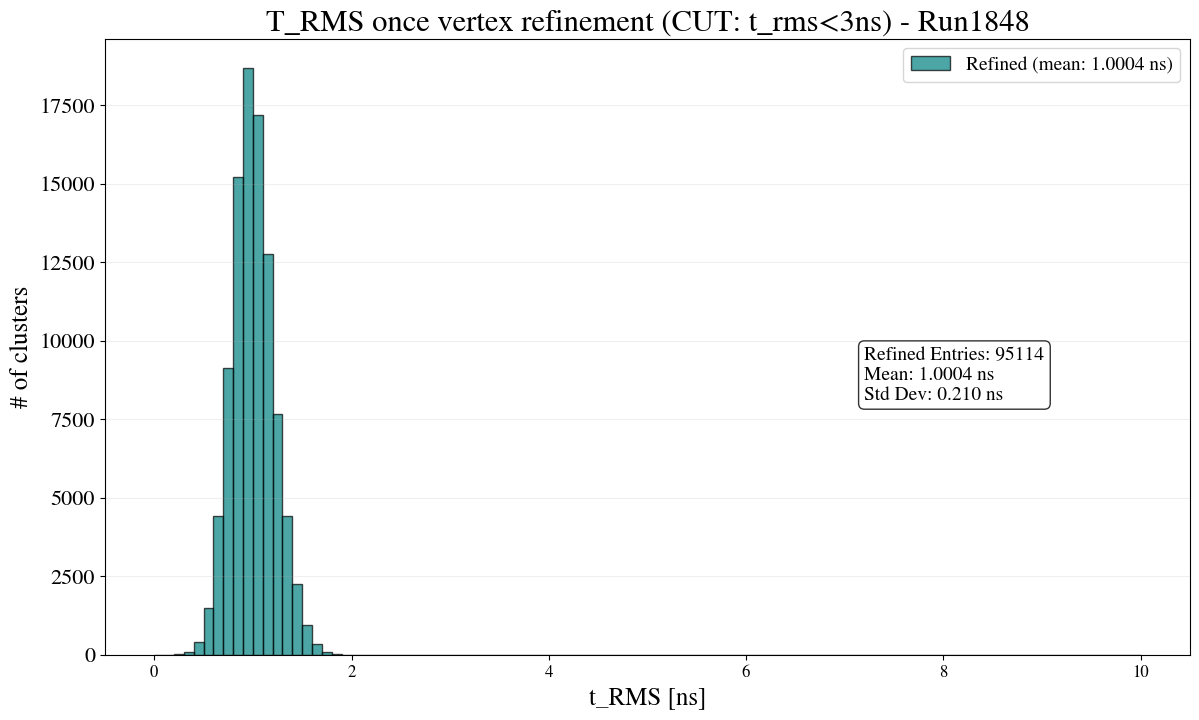

Final refined Mean T_RMS: 1.0004 ns


In [136]:
# 1. Select only the successfully refined clusters
df_plot = df_final[df_final['t_rms_fine'].notna()].copy()

if len(df_plot) == 0:
    print("Zero valid results. Check if the 'guess' or 'clean_mask' logic is too strict.")
else:
    plt.figure(figsize=(14, 8))

    #m1, std1 = df_plot['time_rms'].mean(), df_plot['time_rms'].std()
    m2, std2 = df_plot['t_rms_fine'].mean(), df_plot['t_rms_fine'].std()

    plt.hist(df_plot['t_rms_fine'], bins=100, alpha=0.7, range=[0,10],
             color='teal', label=f'Refined (mean: {m2:.4f} ns)', edgecolor='black')

    plt.title(f"T_RMS once vertex refinement (CUT: t_rms<3ns) - Run{run_number}", fontsize=22)
    plt.xlabel("t_RMS [ns]", fontsize=18)
    plt.ylabel("# of clusters", fontsize=18)
    

    stats_text = (f"Refined Entries: {len(df_plot)}\n"
                  f"Mean: {m2:.4f} ns\n"
                  f"Std Dev: {std2:.3f} ns")
    plt.text(0.7, 0.5, stats_text, transform=plt.gca().transAxes, fontsize=14,
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    plt.legend(loc='upper right', fontsize=14)
    plt.grid(axis='y', alpha=0.2)
    plt.show()

    print(f"Final refined Mean T_RMS: {m2:.4f} ns")

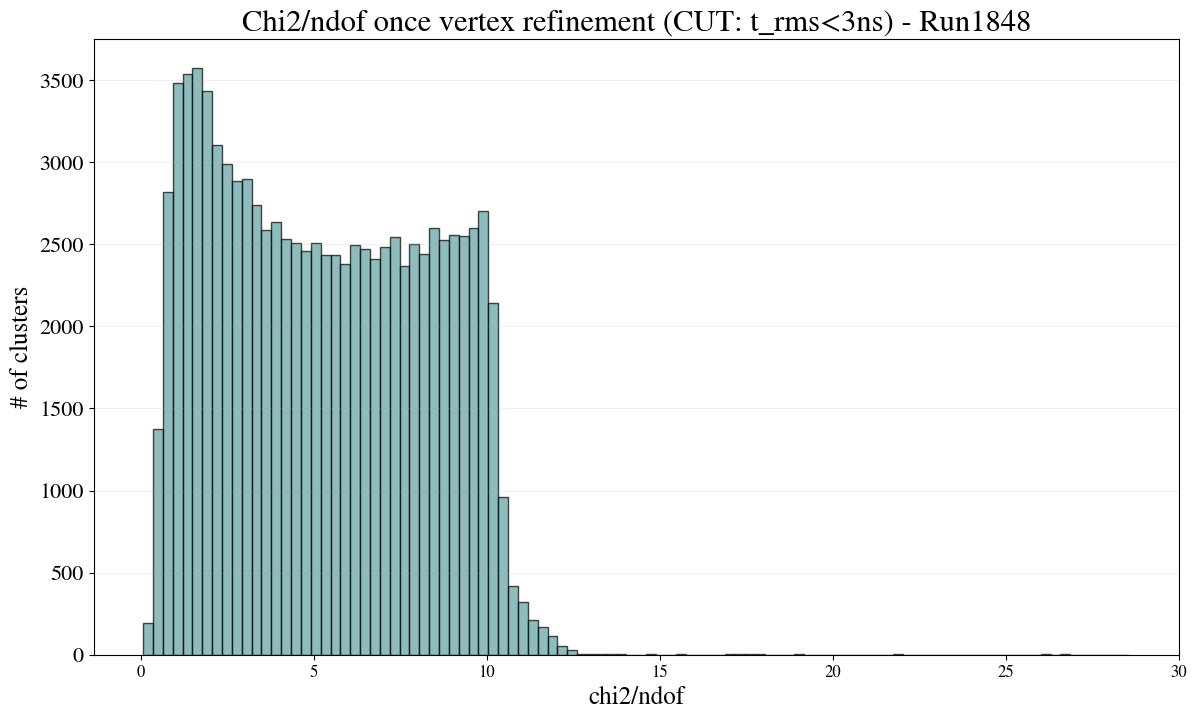

In [137]:
# 1. Select only the successfully refined clusters
df_plot = df_final[df_final['chi2_ndof'].notna()].copy()

if len(df_plot) == 0:
    print("Zero valid results. Check if the 'guess' or 'clean_mask' logic is too strict.")
else:
    plt.figure(figsize=(14, 8))

    plt.hist(df_plot['chi2_ndof'], bins=100, alpha=0.7, color='cadetblue', edgecolor='black')

    plt.title(f"Chi2/ndof once vertex refinement (CUT: t_rms<3ns) - Run{run_number}", fontsize=22)
    plt.xlabel("chi2/ndof", fontsize=18)
    plt.ylabel("# of clusters", fontsize=18)

    plt.grid(axis='y', alpha=0.2)
    plt.show()

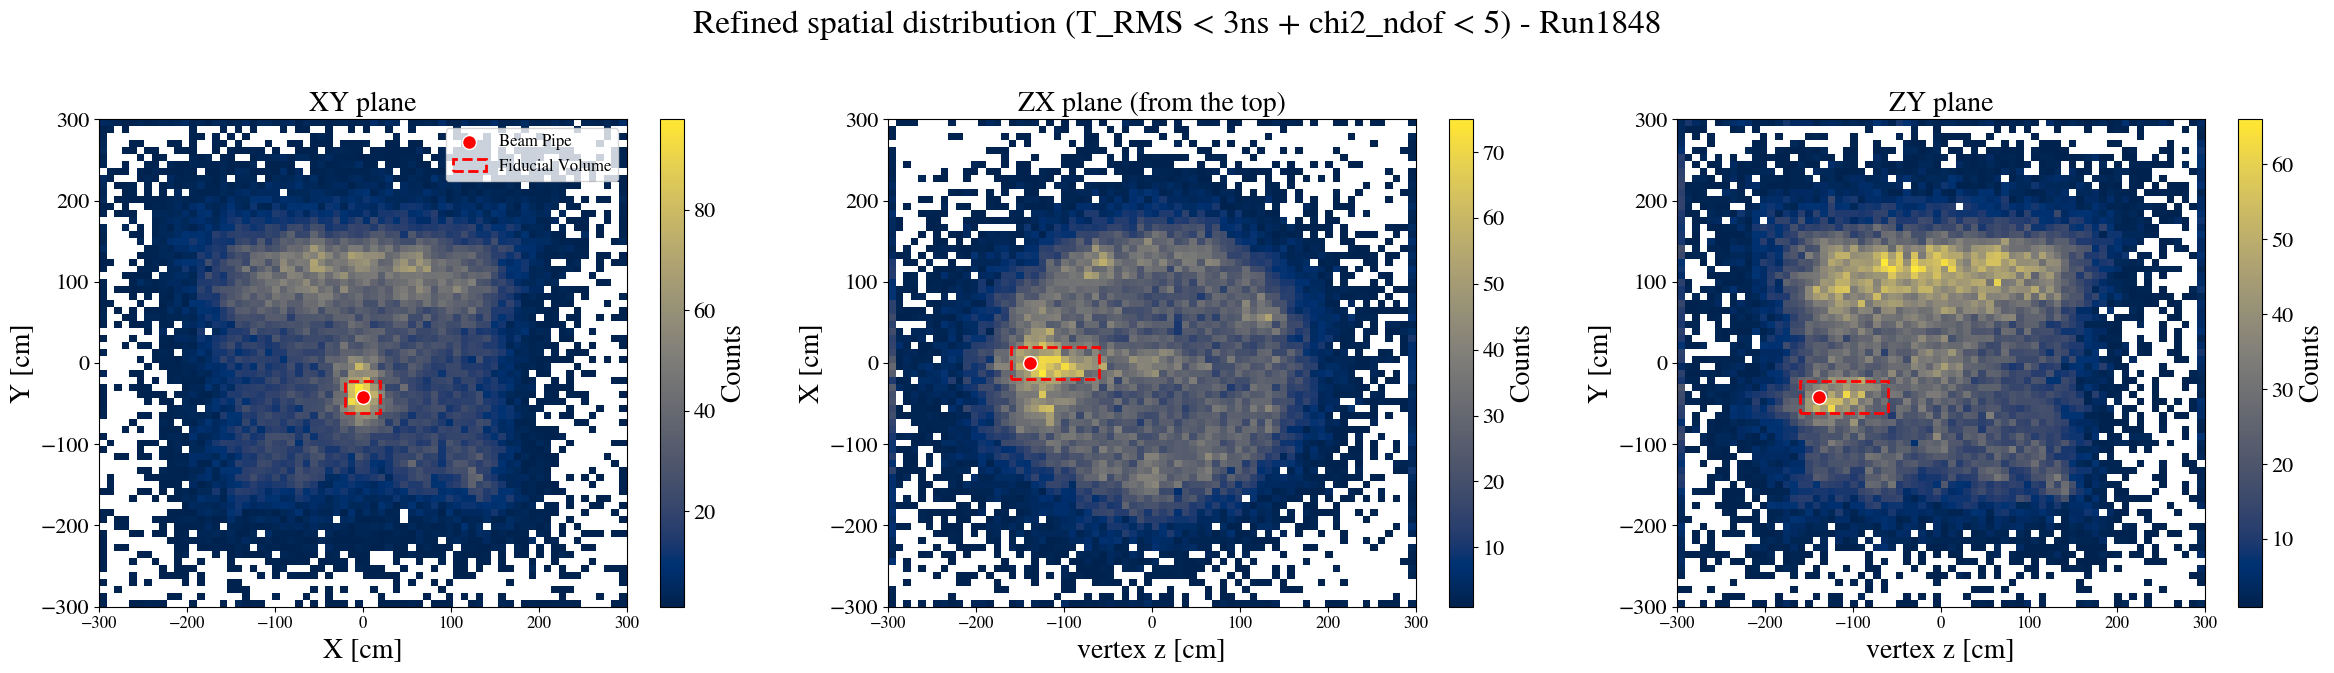

Total clusters analyzed:           661773
Events satisfying mask (refined):  46477
Selection efficiency:              7.02%


In [138]:
import matplotlib.patches as patches

mask_refined = (df_final['v_x_fine'].notna()) & \
               (df_final["chi2_ndof"] < 5) 

df_clean = df_final[mask_refined].copy()

# 2. Setup the figure
fig, axs = plt.subplots(1, 3, figsize=(24, 7))
beam_pipe = [0.0, -42.47, -138.79] 

# Limits for the Fiducial Volume (FV) box
x_lims = [-20, 20]
y_lims = [-62, -22]
z_lims = [-160, -60]

box_style = dict(linewidth=2, edgecolor='red', facecolor='none', linestyle='--')

# --- XY Plane ---
im0 = axs[0].hist2d(df_clean['v_x_fine'], df_clean['v_y_fine'], bins=70, cmap='cividis', cmin=1)
axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe', zorder=10)
rect_xy = patches.Rectangle((x_lims[0], y_lims[0]), x_lims[1]-x_lims[0], y_lims[1]-y_lims[0], **box_style, label='Fiducial Volume')
axs[0].add_patch(rect_xy)
axs[0].set_title("XY plane")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
axs[0].legend(loc='upper right', fontsize=12)
plt.colorbar(im0[3], ax=axs[0], label='Counts')

# --- ZX Plane ---
im1 = axs[1].hist2d(df_clean['v_z_fine'], df_clean['v_x_fine'], bins=70, cmap='cividis', cmin=1)
axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white', zorder=10)
rect_zx = patches.Rectangle((z_lims[0], x_lims[0]), z_lims[1]-z_lims[0], x_lims[1]-x_lims[0], **box_style)
axs[1].add_patch(rect_zx)
axs[1].set_title("ZX plane (from the top)")
axs[1].set_xlabel("vertex z [cm]")
axs[1].set_ylabel("X [cm]")
plt.colorbar(im1[3], ax=axs[1], label='Counts')

# --- ZY Plane ---
im2 = axs[2].hist2d(df_clean['v_z_fine'], df_clean['v_y_fine'], bins=70, cmap='cividis', cmin=1)
axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white', zorder=10)
rect_zy = patches.Rectangle((z_lims[0], y_lims[0]), z_lims[1]-z_lims[0], y_lims[1]-y_lims[0], **box_style)
axs[2].add_patch(rect_zy)
axs[2].set_title("ZY plane")
axs[2].set_xlabel("vertex z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(im2[3], ax=axs[2], label='Counts')

plt.suptitle(f"Refined spatial distribution (T_RMS < 3ns + chi2_ndof < 5) - Run{run_number}", fontsize=24)
plt.tight_layout()
plt.show()

# --- STATISTICS ---
total_events = len(df_all)
passed_events = len(df_clean)
percentage = (passed_events / total_events) * 100


print(f"Total clusters analyzed:           {total_events}")
print(f"Events satisfying mask (refined):  {passed_events}")
print(f"Selection efficiency:              {percentage:.2f}%")


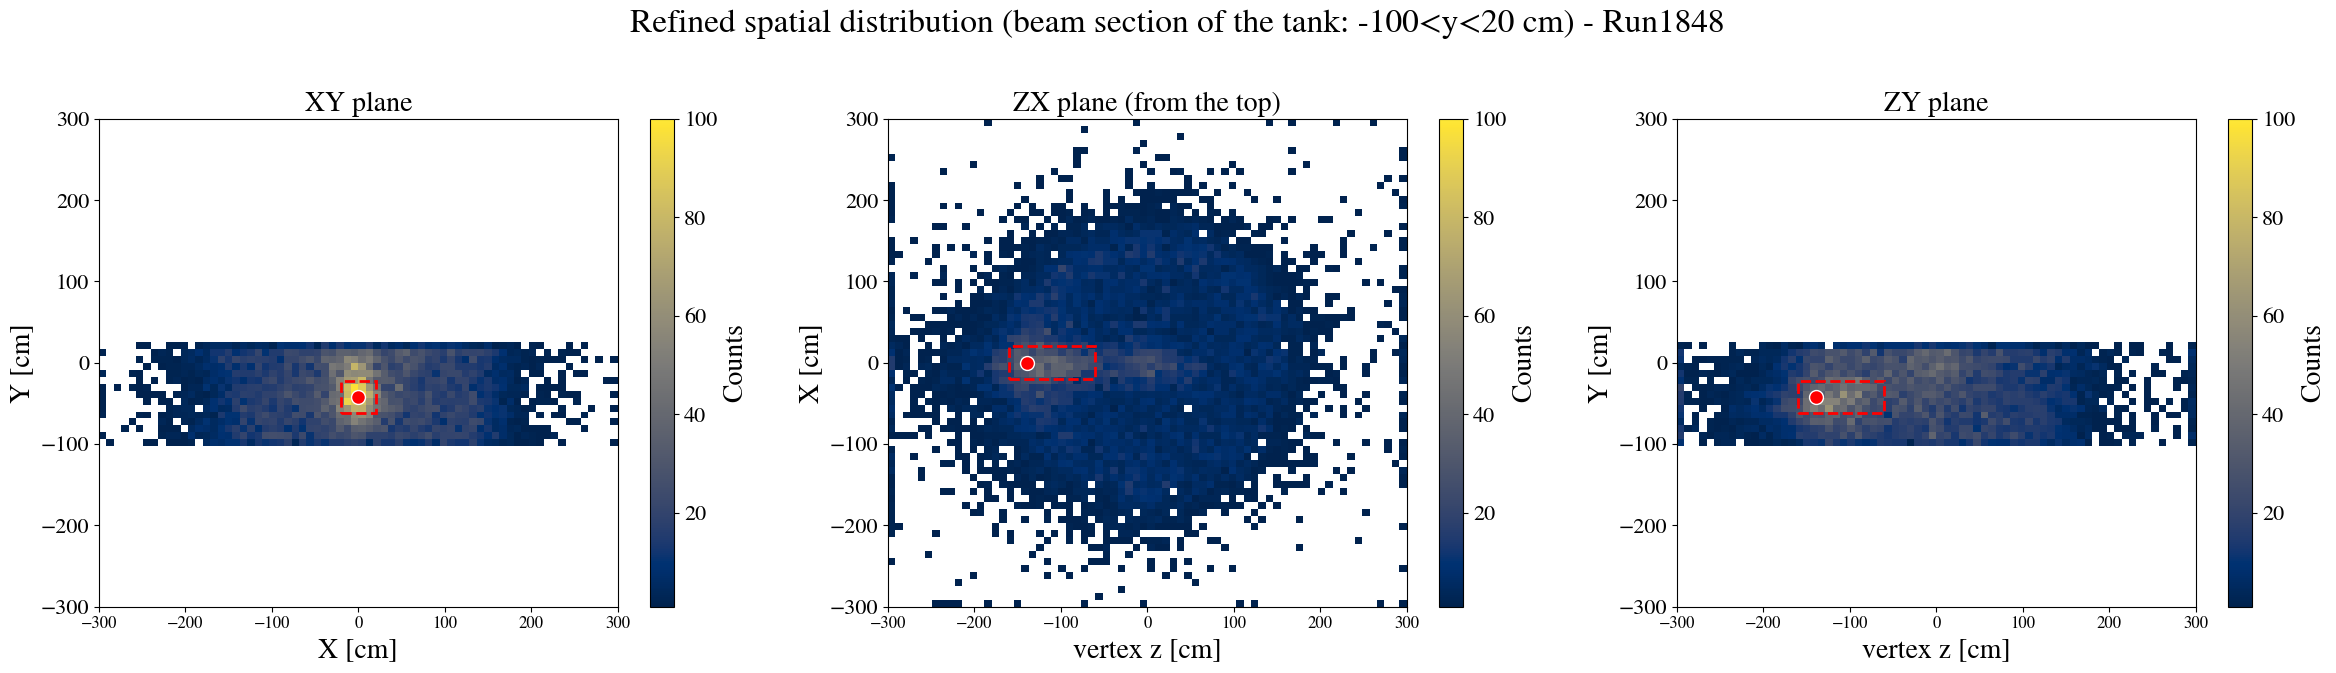

In [139]:
tank_limit = 300 

mask_refined = (df_final['fit_success'] == True) & \
               (df_final["chi2_ndof"] < 5) & \
               (df_final["v_y_fine"] < 20) & \
               (df_final["v_y_fine"] > -100) 

df_clean = df_final[mask_refined].copy()

fig, axs = plt.subplots(1, 3, figsize=(24, 7))
beam_pipe = [0.0, -42.47, -138.79] 
x_lims, y_lims, z_lims = [-20, 20], [-62, -22], [-160, -60]
box_style = dict(linewidth=2, edgecolor='red', facecolor='none', linestyle='--')

# --- CONFIGURACIÓN DE COLORBAR ---
# Ajusta este valor al máximo que veías en tu plot anterior (ej. ~100 o 150)
# para que la densidad de color sea comparable.
VMAX_DENSITY = 100 

# XY plane 
im0 = axs[0].hist2d(df_clean['v_x_fine'], df_clean['v_y_fine'], 
                    bins=70, cmap='cividis', cmin=1, 
                    range=[[-tank_limit, tank_limit], [-tank_limit, tank_limit]],
                    vmax=VMAX_DENSITY)
axs[0].scatter(beam_pipe[0], beam_pipe[1], color='red', s=100, edgecolors='white', label='Beam Pipe', zorder=10)
axs[0].add_patch(patches.Rectangle((x_lims[0], y_lims[0]), x_lims[1]-x_lims[0], y_lims[1]-y_lims[0], **box_style, label='Fiducial Volume'))
axs[0].set_title("XY plane")
axs[0].set_xlabel("X [cm]")
axs[0].set_ylabel("Y [cm]")
plt.colorbar(im0[3], ax=axs[0], label='Counts')

# ZX plane
im1 = axs[1].hist2d(df_clean['v_z_fine'], df_clean['v_x_fine'], 
                    bins=70, cmap='cividis', cmin=1,
                    range=[[-tank_limit, tank_limit], [-tank_limit, tank_limit]],
                    vmax=VMAX_DENSITY)
axs[1].scatter(beam_pipe[2], beam_pipe[0], color='red', s=100, edgecolors='white', zorder=10)
axs[1].add_patch(patches.Rectangle((z_lims[0], x_lims[0]), z_lims[1]-z_lims[0], x_lims[1]-x_lims[0], **box_style))
axs[1].set_title("ZX plane (from the top)")
axs[1].set_xlabel("vertex z [cm]")
axs[1].set_ylabel("X [cm]")
plt.colorbar(im1[3], ax=axs[1], label='Counts')

# ZY plane 
im2 = axs[2].hist2d(df_clean['v_z_fine'], df_clean['v_y_fine'], 
                    bins=70, cmap='cividis', cmin=1,
                    range=[[-tank_limit, tank_limit], [-tank_limit, tank_limit]],
                    vmax=VMAX_DENSITY)
axs[2].scatter(beam_pipe[2], beam_pipe[1], color='red', s=100, edgecolors='white', zorder=10)
axs[2].add_patch(patches.Rectangle((z_lims[0], y_lims[0]), z_lims[1]-z_lims[0], y_lims[1]-y_lims[0], **box_style))
axs[2].set_title("ZY plane")
axs[2].set_xlabel("vertex z [cm]")
axs[2].set_ylabel("Y [cm]")
plt.colorbar(im2[3], ax=axs[2], label='Counts')

# force tank limits
for ax in axs:
    ax.set_xlim(-tank_limit, tank_limit)
    ax.set_ylim(-tank_limit, tank_limit)

plt.suptitle(f"Refined spatial distribution (beam section of the tank: -100<y<20 cm) - Run{run_number}", fontsize=24)
plt.tight_layout()
plt.show()

In [140]:
fv_mask = (df_final['fit_success'] == True) & \
          (df_final['v_x_fine'] >= x_lims[0]) & (df_final['v_x_fine'] <= x_lims[1]) & \
          (df_final['v_y_fine'] >= y_lims[0]) & (df_final['v_y_fine'] <= y_lims[1]) & \
          (df_final['v_z_fine'] >= z_lims[0]) & (df_final['v_z_fine'] <= z_lims[1]) & \
          (df_final["chi2_ndof"] < 5)

df_fv = df_final[fv_mask].copy()
df_fv['t_ms'] = df_fv['t_window_start_rel_ns'] / 1e6

print(f"Total candidates in fiducial volume: {len(df_fv)}")

Total candidates in fiducial volume: 834


# WE SAVE THE FILTERED CLUSTER CANDIDATES!

In [147]:
output_dir = "/scratch/elena/9Li/results/filtered_cluster_candidates"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

filename = f"{output_dir}/df_fv_run{run_number}_n{len(df_fv)}.pkl"

df_fv['run_number'] = run_number  
df_fv.to_pickle(filename)

print(f"Run {run_number} save!")
print(f"File name: {filename}")
print(f"Filtered number of cluster candidates saved: {len(df_fv)}")

Run 1848 save!
File name: /scratch/elena/9Li/results/filtered_cluster_candidates/df_fv_run1848_n834.pkl
Filtered number of cluster candidates saved: 834


/tmp/ipykernel_2212718/953492193.py:10: RuntimeWarning: overflow encountered in exp
  return N0 * np.exp(-t / tau) + C


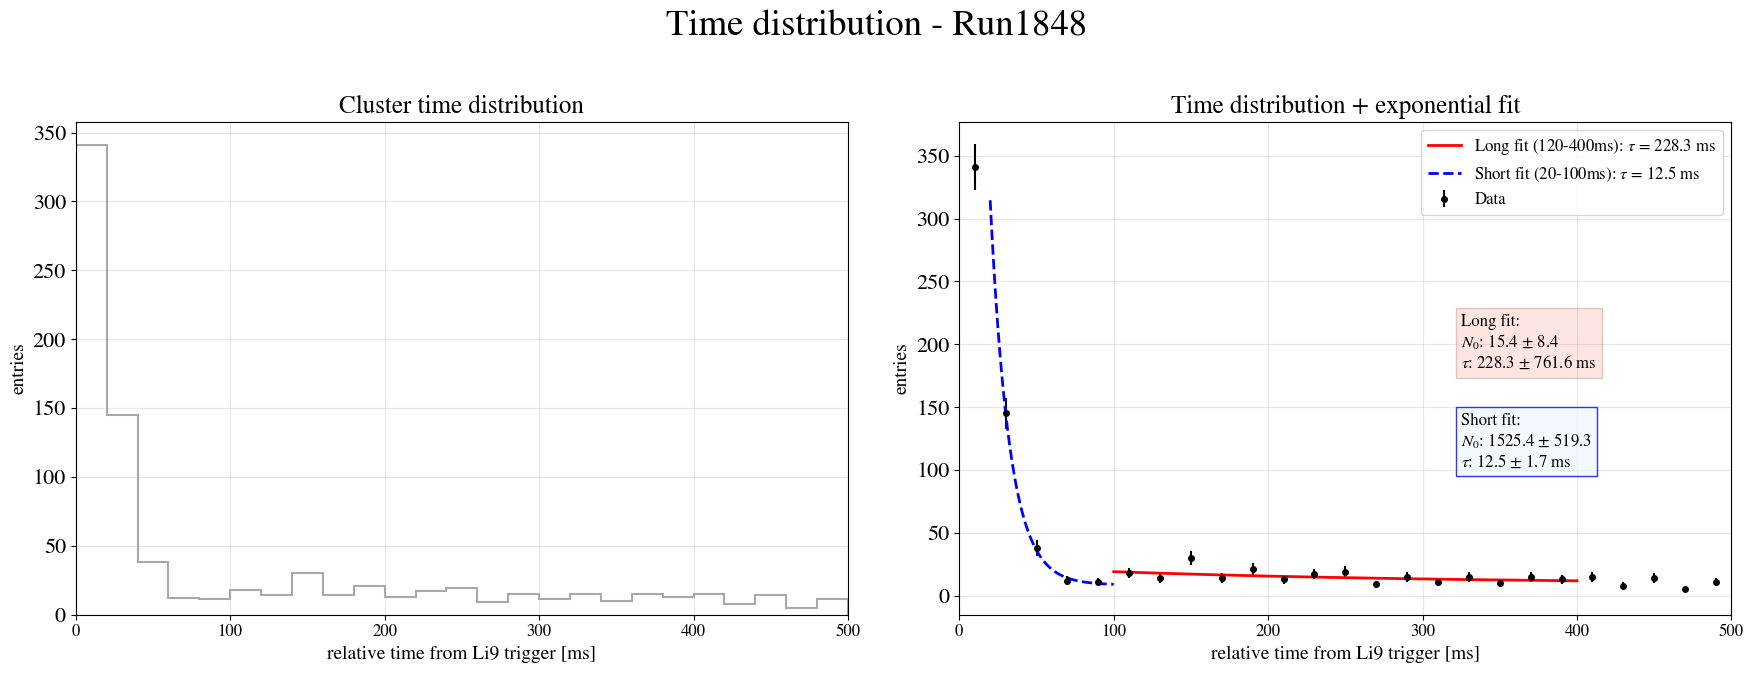

Resultado del ajuste: tau = 228.29 +/- 761.65 ms


In [143]:
from scipy.optimize import curve_fit

bin_width = 20
full_bins = np.arange(0, 500 + bin_width, bin_width)
counts, edges = np.histogram(df_fv['t_ms'], bins=full_bins)
centers = (edges[:-1] + edges[1:]) / 2


def decay_func(t, N0, tau, C):
    return N0 * np.exp(-t / tau) + C

mask_fit = (centers >= 100) & (centers <= 400)
x_fit = centers[mask_fit]
y_fit = counts[mask_fit]

mask_short = (centers >= 20) & (centers <= 100)
x_short = centers[mask_short]
y_short = counts[mask_short]


# Estimación inicial: [N0, tau, C]
p0 = [y_fit.max(), 250.0, y_fit.min()]
p0_short = [y_short.max(), 14.0, y_short.min()]

# Ejecución del ajuste
popt, pcov = curve_fit(decay_func, x_fit, y_fit, p0=p0, sigma=np.sqrt(y_fit + 1))
perr = np.sqrt(np.diag(pcov))

popt_s, pcov_s = curve_fit(decay_func, x_short, y_short, p0=p0_short, sigma=np.sqrt(y_short + 1))
perr_s = np.sqrt(np.diag(pcov_s))


#PLOTS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))

ax1.hist(df_fv['t_ms'], bins=full_bins, histtype='step', color='darkgray', lw=1.5)
ax1.set_title("Cluster time distribution", fontsize=18)
ax1.set_xlabel("relative time from Li9 trigger [ms]", fontsize=14)
ax1.set_ylabel("entries", fontsize=14)
ax1.set_xlim(0, 500)
ax1.grid(alpha=0.3)


ax2.errorbar(centers, counts, yerr=np.sqrt(counts), fmt='ko', markersize=4, label='Data')
t_fine = np.linspace(100, 400, 200)
ax2.plot(t_fine, decay_func(t_fine, *popt), 'r-', lw=2, label=f'Long fit (120-400ms): $\\tau$ = {popt[1]:.1f} ms')
t_short_plot = np.linspace(20, 100, 100)
ax2.plot(t_short_plot, decay_func(t_short_plot, *popt_s), 'b--', lw=2, label=f'Short fit (20-100ms): $\\tau$ = {popt_s[1]:.1f} ms')


res_text = (f"Long fit:\n"
            f"$N_0$: {popt[0]:.1f} ± {perr[0]:.1f}\n"
            f"$\\tau$: {popt[1]:.1f} ± {perr[1]:.1f} ms")
        

res_short = (f"Short fit:\n"
             f"$N_0$: {popt_s[0]:.1f} ± {perr_s[0]:.1f}\n"
             f"$\\tau$: {popt_s[1]:.1f} ± {perr_s[1]:.1f} ms")

ax2.text(0.65, 0.5, res_text, transform=ax2.transAxes, fontsize=12,
         bbox=dict(facecolor='salmon', alpha=0.2, edgecolor='darkred'))
ax2.text(0.65, 0.30, res_short, transform=ax2.transAxes, fontsize=12,
         bbox=dict(facecolor='aliceblue', alpha=0.8, edgecolor='blue'))


ax2.set_title("Time distribution + exponential fit", fontsize=18)
ax2.set_xlabel("relative time from Li9 trigger [ms]", fontsize=14)
ax2.set_ylabel("entries", fontsize=14)
ax2.set_xlim(0, 500)
ax2.legend(fontsize=12)
ax2.grid(alpha=0.3)

plt.suptitle(f"Time distribution - Run{run_number}")
plt.tight_layout()
plt.show()

print(f"Resultado del ajuste: tau = {popt[1]:.2f} +/- {perr[1]:.2f} ms")

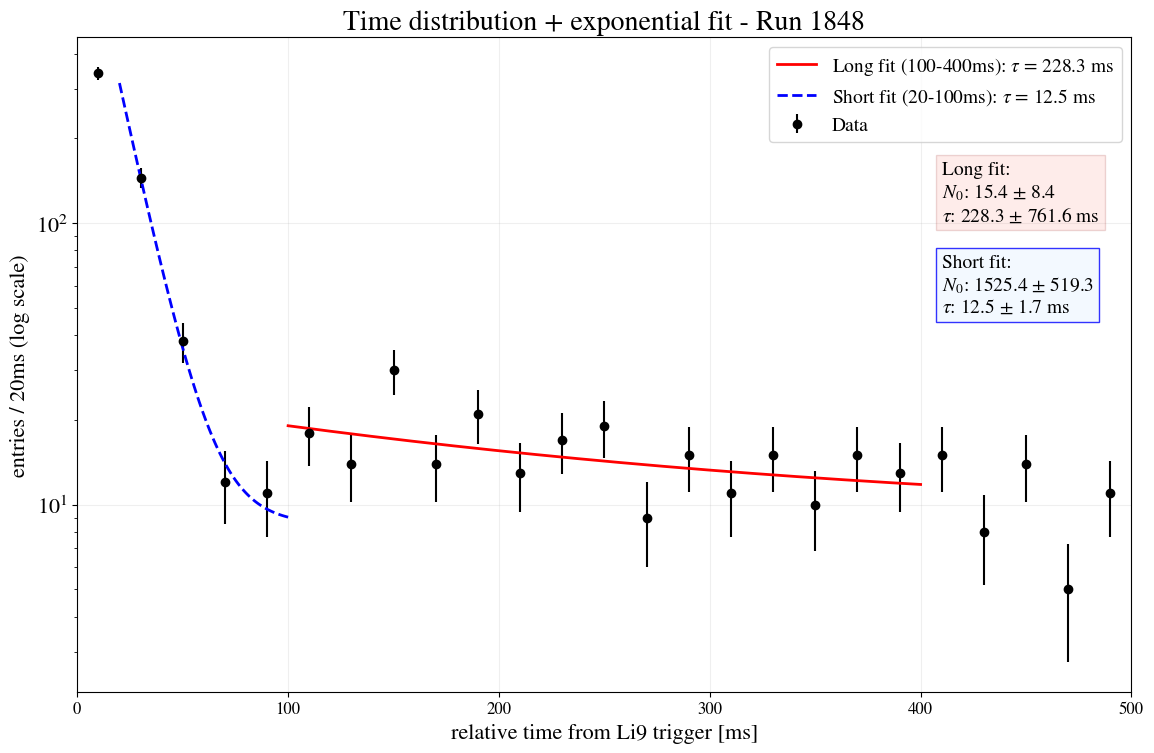

Resultado final Li9: tau = 228.29 +/- 761.65 ms
Resultado final B12: tau = 12.45 +/- 1.69 ms


In [144]:

fig, ax2 = plt.subplots(figsize=(12, 8))

# Datos experimentales (todos los puntos)
ax2.errorbar(centers, counts, yerr=np.sqrt(counts), fmt='ko', markersize=6, label='Data')

t_fine = np.linspace(100, 400, 200)
ax2.plot(t_fine, decay_func(t_fine, *popt), 'r-', lw=2, label=f'Long fit (100-400ms): $\\tau$ = {popt[1]:.1f} ms')

t_short_plot = np.linspace(20, 100, 100)
ax2.plot(t_short_plot, decay_func(t_short_plot, *popt_s), 'b--', lw=2, label=f'Short fit (20-100ms): $\\tau$ = {popt_s[1]:.1f} ms')

res_text = (f"Long fit:\n"
            f"$N_0$: {popt[0]:.1f} ± {perr[0]:.1f}\n"
            f"$\\tau$: {popt[1]:.1f} ± {perr[1]:.1f} ms")
        
res_short = (f"Short fit:\n"
             f"$N_0$: {popt_s[0]:.1f} ± {perr_s[0]:.1f}\n"
             f"$\\tau$: {popt_s[1]:.1f} ± {perr_s[1]:.1f} ms")

ax2.text(0.82, 0.72, res_text, transform=ax2.transAxes, fontsize=14,
         bbox=dict(facecolor='salmon', alpha=0.15, edgecolor='darkred'))
ax2.text(0.82, 0.58, res_short, transform=ax2.transAxes, fontsize=14,
         bbox=dict(facecolor='aliceblue', alpha=0.8, edgecolor='blue'))


ax2.set_title(f"Time distribution + exponential fit - Run {run_number}", fontsize=20)
ax2.set_xlabel("relative time from Li9 trigger [ms]", fontsize=16)
ax2.set_ylabel(f"entries / {bin_width}ms (log scale)", fontsize=16)
ax2.set_xlim(0, 500)
ax2.legend(fontsize=14, loc='upper right')
ax2.grid(alpha=0.2)

plt.yscale("log")
plt.tight_layout()
plt.show()

print(f"Resultado final Li9: tau = {popt[1]:.2f} +/- {perr[1]:.2f} ms")
print(f"Resultado final B12: tau = {popt_s[1]:.2f} +/- {perr_s[1]:.2f} ms")

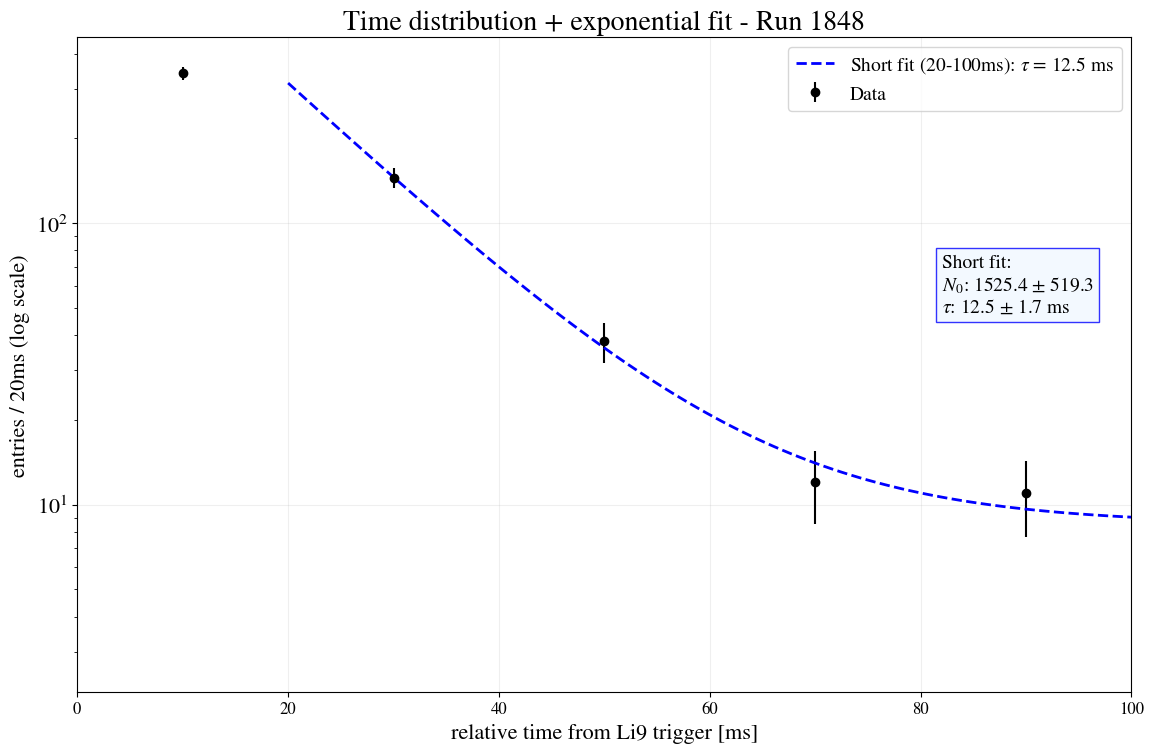

In [145]:

fig, ax2 = plt.subplots(figsize=(12, 8))

# Datos experimentales (todos los puntos)
ax2.errorbar(centers, counts, yerr=np.sqrt(counts), fmt='ko', markersize=6, label='Data')


t_short_plot = np.linspace(20, 100, 100)
ax2.plot(t_short_plot, decay_func(t_short_plot, *popt_s), 'b--', lw=2, label=f'Short fit (20-100ms): $\\tau$ = {popt_s[1]:.1f} ms')

        
res_short = (f"Short fit:\n"
             f"$N_0$: {popt_s[0]:.1f} ± {perr_s[0]:.1f}\n"
             f"$\\tau$: {popt_s[1]:.1f} ± {perr_s[1]:.1f} ms")

ax2.text(0.82, 0.58, res_short, transform=ax2.transAxes, fontsize=14,
         bbox=dict(facecolor='aliceblue', alpha=0.8, edgecolor='blue'))


ax2.set_title(f"Time distribution + exponential fit - Run {run_number}", fontsize=20)
ax2.set_xlabel("relative time from Li9 trigger [ms]", fontsize=16)
ax2.set_ylabel(f"entries / {bin_width}ms (log scale)", fontsize=16)
ax2.set_xlim(0, 100)
ax2.legend(fontsize=14, loc='upper right')
ax2.grid(alpha=0.2)

plt.yscale("log")
plt.tight_layout()
plt.show()


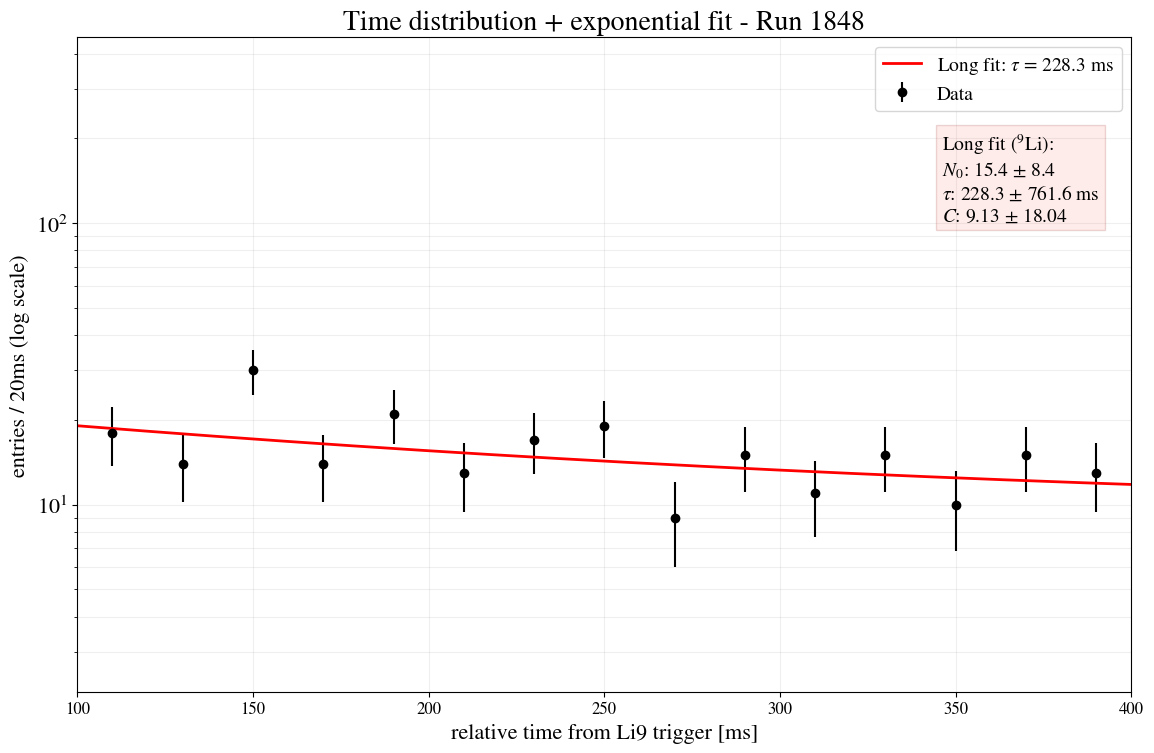

In [146]:
fig, ax2 = plt.subplots(figsize=(12, 8))

ax2.errorbar(centers, counts, yerr=np.sqrt(counts), fmt='ko', markersize=6, label='Data')

t_plot = np.linspace(100, 400, 200)
ax2.plot(t_plot, decay_func(t_plot, *popt), 'r-', lw=2, label=f'Long fit: $\\tau$ = {popt[1]:.1f} ms')

res_text = (f"Long fit ($^{9}$Li):\n"
            f"$N_0$: {popt[0]:.1f} ± {perr[0]:.1f}\n"
            f"$\\tau$: {popt[1]:.1f} ± {perr[1]:.1f} ms\n"
            f"$C$: {popt[2]:.2f} ± {perr[2]:.2f}")

ax2.text(0.82, 0.72, res_text, transform=ax2.transAxes, fontsize=14,
         bbox=dict(facecolor='salmon', alpha=0.15, edgecolor='darkred'))


ax2.set_title(f"Time distribution + exponential fit - Run {run_number}", fontsize=20)
ax2.set_xlabel("relative time from Li9 trigger [ms]", fontsize=16)
ax2.set_ylabel(f"entries / {bin_width}ms (log scale)", fontsize=16)


ax2.set_xlim(100, 400) 
ax2.set_yscale("log")
ax2.grid(True, which="both", ls="-", alpha=0.2)
ax2.legend(fontsize=14)

plt.tight_layout()
plt.show()